In [1]:
import os
import geopandas as gpd
import rasterio
from rasterio.plot import show
from rasterio.mask import mask
import matplotlib.pyplot as plt
from shapely.geometry import Point
from ipyleaflet import Map, Marker, Polygon, basemaps, basemap_to_tiles
from ipywidgets import Output, Dropdown, Button, Text
import pandas as pd
import folium
from folium.plugins import Draw
from ipywidgets import Output
from IPython.display import display
import numpy as np
import contextily as ctx
from shapely.geometry import box
from IPython.display import display, HTML
import ipywidgets as widgets

In [14]:
#set working directory
os.chdir("C:/Users/Mukaratirwar/OneDrive - Food and Agriculture Organization/Desktop/GAEZ_analysis/Bhima_basin/Soil_data")

In [2]:
os.getcwd()   

'C:\\Users\\Mukaratirwar\\OneDrive - Food and Agriculture Organization\\Desktop\\SOILFER\\Soil_idenification_algorithm'

In [15]:
# Load the HWSD dataset
HWSD_dataset = rasterio.open("HWSD2_RASTER/HWSD2.bil")
df = pd.read_csv("C:/Users/Mukaratirwar/OneDrive - Food and Agriculture Organization/Desktop/GAEZ_analysis/HWSD2_LAYERS.csv")

C:\Users\Mukaratirwar\AppData\Local\Temp\ipykernel_16040\4185089126.py:3: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("C:/Users/Mukaratirwar/OneDrive - Food and Agriculture Organization/Desktop/GAEZ_analysis/HWSD2_LAYERS.csv")


In [16]:
# Output widget to display messages in Jupyter
out = Output()

# Global variable to store selected coordinates
selected_coordinates = None

# Step 1: Select Point on Map and Save Coordinates
def select_point_on_map(center_coordinates=[37.7749, -122.4194], zoom_start=12):
    # Create a folium map centered on provided coordinates
    m = folium.Map(location=center_coordinates, zoom_start=zoom_start)

    # Add drawing options to allow only marker placement
    draw = Draw(draw_options={
        "polyline": False, "polygon": False, "circle": False, "rectangle": False, "circlemarker": False, "marker": True
    })
    draw.add_to(m)

    # Display instructions to manually record coordinates
    with out:
        out.clear_output()
        print("Please place a marker on the map to select a point.")
        print("Once you have drawn a marker, right-click on the marker to view its coordinates.")
        print("Manually copy the coordinates, and use them in the following steps.")

    # Display the map and instructions
    display(m)
    display(out)

# Display the map for point selection
select_point_on_map()


Please place a marker on the map to select a point.
Once you have drawn a marker, right-click on the marker to view its coordinates.
Manually copy the coordinates, and use them in the following steps.


Output()

In [28]:
#enter your coordinates here, and make sure they are in the correct order 
selected_coordinates = [49.02326,10.283203] 

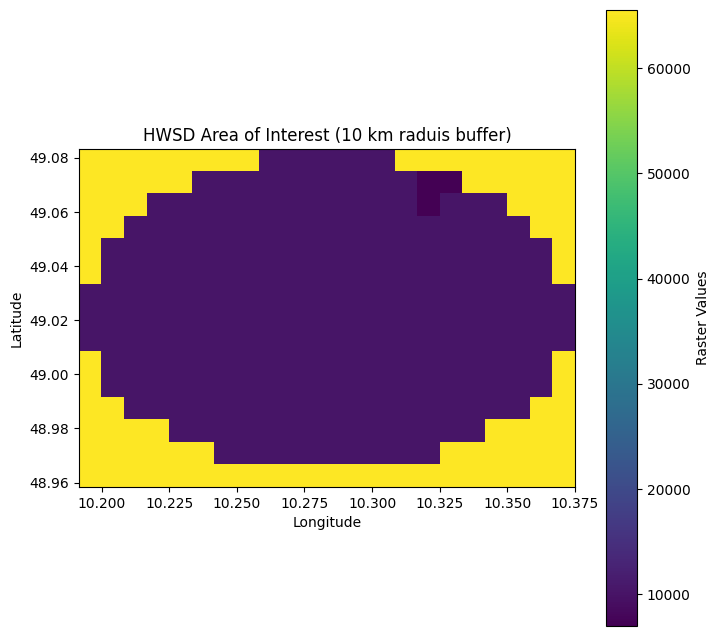

In [31]:
# Step 2: Generate Buffer around the Selected Point and Add to Map
buffer_geometry = None
def generate_and_display_buffer(buffer_radius_km=10):
    global buffer_geometry, selected_coordinates
    if selected_coordinates is None:
        print("Please select a point on the map first.")
        return None
    
    # Create a buffer around the selected point
    point = Point(selected_coordinates[1], selected_coordinates[0])
    gdf = gpd.GeoDataFrame(geometry=[point], crs='EPSG:4326')
    gdf = gdf.to_crs(epsg=3857)  # Metric CRS for buffering
    buffer_geometry = gdf.geometry.buffer(buffer_radius_km * 1000)  # Buffer in meters
    gdf = gpd.GeoDataFrame(geometry=buffer_geometry, crs="EPSG:3857").to_crs("EPSG:4326")
    
    # Create a new map centered on the selected coordinates with a closer zoom level
    map_with_buffer = folium.Map(location=[selected_coordinates[0], selected_coordinates[1]], zoom_start=13)
    
    # Add a circle representing the buffer on the map
    folium.Circle(
        location=[selected_coordinates[0], selected_coordinates[1]],
        radius=buffer_radius_km * 1000,
        color="blue",
        fill=True,
        fill_opacity=0.2
    ).add_to(map_with_buffer)

    # Display the updated map with the buffer circle
    display(map_with_buffer)
    return gdf

# Run this function after assigning coordinates manually to `selected_coordinates`
buffer_gdf = generate_and_display_buffer(buffer_radius_km=10)



# Define paths
raster_path = 'HWSD2_RASTER/HWSD2.bil'
output_path = 'clipped_raster.tif'  # Path to save the clipped raster

# Reproject buffer_gdf to match the raster's CRS if necessary
with rasterio.open(raster_path) as src:
    raster_crs = src.crs

    if buffer_gdf.crs != raster_crs:
        buffer_gdf = buffer_gdf.to_crs(raster_crs)

    # Clip the raster using the buffer_gdf geometry
    out_image, out_transform = mask(src, buffer_gdf.geometry, crop=True)
    out_meta = src.meta.copy()
    out_meta.update({
        "driver": "GTiff",
        "height": out_image.shape[1],
        "width": out_image.shape[2],
        "transform": out_transform,
        "crs": raster_crs
    })

    # Save the clipped raster to a new file
    with rasterio.open(output_path, "w", **out_meta) as dest:
        dest.write(out_image)

# Display the saved clipped raster
with rasterio.open(output_path) as src:
    fig, ax = plt.subplots(figsize=(8, 8))
    extent = (
        src.bounds.left,
        src.bounds.right,
        src.bounds.bottom,
        src.bounds.top
    )
    clipped_plot = ax.imshow(src.read(1), cmap='viridis', extent=extent)
    ax.set_xlim(extent[0], extent[1])
    ax.set_ylim(extent[2], extent[3])
    ax.set_title("HWSD Area of Interest (10 km raduis buffer)")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.colorbar(clipped_plot, ax=ax, label="Raster Values")
    plt.show()


In [24]:
# Define paths
raster_path = 'HWSD2_RASTER/HWSD2.bil'
output_table_path = 'raster_values_within_buffer.csv'  # Path to save the table

# Reproject buffer_gdf to match the raster's CRS if necessary
with rasterio.open(raster_path) as src:
    raster_crs = src.crs
    if buffer_gdf.crs != raster_crs:
        buffer_gdf = buffer_gdf.to_crs(raster_crs)

    # Clip the raster using the buffer_gdf geometry
    out_image, out_transform = mask(src, buffer_gdf.geometry, crop=True)
    
    # Extract band 1
    band1 = out_image[0]

# Flatten the array and remove no-data values
band1_flat = band1.flatten()
band1_flat = band1_flat[band1_flat != src.nodata]  # Exclude no-data values

# Calculate the counts and proportions of each unique value
unique, counts = np.unique(band1_flat, return_counts=True)
total_count = counts.sum()
proportions = counts / total_count

# Create a DataFrame
data = {
    "HWSD2_SMU_ID": unique,
    "Count": counts,
    "Proportion": proportions
}
df = pd.DataFrame(data)

# Save the DataFrame to a CSV file
df.to_csv(output_table_path, index=False)

# Display the DataFrame for inspection
print(df)


   HWSD2_SMU_ID  Count  Proportion
0          4606    274    0.958042
1          4646     12    0.041958


In [38]:
# Load the soil unit share table (already available as 'df')
soil_unit_share_table = df  # This should already contain your HWSD2_SMU_ID, Count, and Proportion

# Load the detailed HWSD2 data from the specified CSV file
excel_path = "C:/Users/Mukaratirwar/OneDrive - Food and Agriculture Organization/Desktop/GAEZ_analysis/HWSD2_LAYERS.csv"
hwsd_data = pd.read_csv(excel_path, low_memory=False)

# Get unique HWSD2_SMU_IDs from the soil unit share table
matching_ids = soil_unit_share_table["HWSD2_SMU_ID"].unique()

# Filter the detailed HWSD2 data for rows where HWSD2_SMU_ID matches those in the soil unit share table
filtered_data = hwsd_data[hwsd_data["HWSD2_SMU_ID"].isin(matching_ids)]

# Display the filtered data
print("Detailed Information for Matching HWSD2_SMU_IDs:")
print(filtered_data)


Detailed Information for Matching HWSD2_SMU_IDs:
            ID  HWSD2_SMU_ID NSC_MU_SOURCE1 NSC_MU_SOURCE2 WISE30s_SMU_ID  \
15182    15183          9839            NaN            NaN     WD30009839   
15201    15202          9838            NaN            NaN     WD30009838   
15214    15215          9839            NaN            NaN     WD30009839   
15233    15234          9838            NaN            NaN     WD30009838   
15246    15247          9839            NaN            NaN     WD30009839   
...        ...           ...            ...            ...            ...   
296850  296851          9840            NaN            NaN     WD30009840   
297004  297005          9840            NaN            NaN     WD30009840   
297158  297159          9840            NaN            NaN     WD30009840   
297333  297334          9840            NaN            NaN     WD30009840   
297445  297446          9840            NaN            NaN     WD30009840   

        HWSD1_SMU_ID  COVE

In [40]:
# Select only the columns needed and filter rows where LAYER is 'D1'
columns_to_keep = ['HWSD2_SMU_ID', 'SHARE', 'WRB2', 'ROOT_DEPTH', 'DRAINAGE', 
                   'LAYER', 'COARSE', 'SAND', 'SILT', 'CLAY', 'TEXTURE_USDA']

# Filter data for relevant columns and where LAYER is 'D1'
filtered_data = filtered_data[filtered_data['LAYER'] == 'D1'][columns_to_keep]

# Remove rows where 'TEXTURE_USDA' is NaN
filtered_data = filtered_data.dropna(subset=['TEXTURE_USDA'])

# Merge filtered_data with soil_unit_share_table to get the Proportion column
adjusted_data = pd.merge(
    filtered_data,
    soil_unit_share_table[['HWSD2_SMU_ID', 'Proportion']],
    on='HWSD2_SMU_ID',
    how='left'
)

# Convert Proportion to percentage
adjusted_data['Proportion'] = adjusted_data['Proportion'] * 100

# Calculate the adjusted share based on the Proportion for each HWSD2_SMU_ID
adjusted_data['Adjusted_SHARE'] = adjusted_data['SHARE'] * (adjusted_data['Proportion'] / 100)

# Arrange columns to show original SHARE, Adjusted_SHARE, and Proportion in percentage
adjusted_data = adjusted_data.rename(columns={'Proportion': 'Proportion (%)'})
adjusted_data = adjusted_data[['HWSD2_SMU_ID', 'SHARE', 'Adjusted_SHARE', 'Proportion (%)', 
                               'WRB2', 'ROOT_DEPTH', 'DRAINAGE', 'LAYER', 'COARSE', 
                               'SAND', 'SILT', 'CLAY', 'TEXTURE_USDA']]

# Display the new DataFrame
print("New DataFrame with Original and Adjusted SHARE Values, with Proportion in Percentage:")
print(adjusted_data)


New DataFrame with Original and Adjusted SHARE Values, with Proportion in Percentage:
    HWSD2_SMU_ID  SHARE  Adjusted_SHARE  Proportion (%) WRB2  ROOT_DEPTH  \
0           9839     10        0.220588        2.205882   AN         1.0   
1           9838     10        1.433824       14.338235   AN         1.0   
2           9834     70        9.264706       13.235294   CM         3.0   
3           9839     25        0.551471        2.205882   CM         1.0   
4           9838     25        3.584559       14.338235   CM         1.0   
5           9840     50        3.492647        6.985294   CM         1.0   
6           9839     43        0.948529        2.205882   CM         3.0   
7           9838     43        6.165441       14.338235   CM         3.0   
8           9840     15        1.047794        6.985294   CM         1.0   
9           9840     30        2.095588        6.985294   FL         1.0   
10          9838      2        0.286765       14.338235   LP         4.0   
11

In [41]:
# Select only the columns needed and filter rows where LAYER is 'D1'
columns_to_keep = ['HWSD2_SMU_ID', 'SHARE', 'WRB2', 'ROOT_DEPTH', 'DRAINAGE', 
                   'LAYER', 'COARSE', 'SAND', 'SILT', 'CLAY', 'TEXTURE_USDA']

# Filter data for relevant columns and where LAYER is 'D1'
filtered_data = filtered_data[filtered_data['LAYER'] == 'D1'][columns_to_keep]

# Remove rows where 'TEXTURE_USDA' is NaN
filtered_data = filtered_data.dropna(subset=['TEXTURE_USDA'])

# Merge filtered_data with soil_unit_share_table to get the Proportion column
adjusted_data = pd.merge(
    filtered_data,
    soil_unit_share_table[['HWSD2_SMU_ID', 'Proportion']],
    on='HWSD2_SMU_ID',
    how='left'
)

# Convert Proportion to percentage
adjusted_data['Proportion'] = adjusted_data['Proportion'] * 100

# Calculate the adjusted share based on the Proportion for each HWSD2_SMU_ID
adjusted_data['Adjusted_SHARE'] = adjusted_data['SHARE'] * (adjusted_data['Proportion'] / 100)

# Arrange columns to show original SHARE, Adjusted_SHARE, and Proportion in percentage
adjusted_data = adjusted_data.rename(columns={'Proportion': 'Proportion (%)'})
adjusted_data = adjusted_data[['HWSD2_SMU_ID', 'SHARE', 'Adjusted_SHARE', 'Proportion (%)', 
                               'WRB2', 'ROOT_DEPTH', 'DRAINAGE', 'LAYER', 'COARSE', 
                               'SAND', 'SILT', 'CLAY', 'TEXTURE_USDA']]

# Display the new DataFrame
print("New DataFrame with Original and Adjusted SHARE Values, with Proportion in Percentage:")
print(adjusted_data)


New DataFrame with Original and Adjusted SHARE Values, with Proportion in Percentage:
    HWSD2_SMU_ID  SHARE  Adjusted_SHARE  Proportion (%) WRB2  ROOT_DEPTH  \
0           9839     10        0.220588        2.205882   AN         1.0   
1           9838     10        1.433824       14.338235   AN         1.0   
2           9834     70        9.264706       13.235294   CM         3.0   
3           9839     25        0.551471        2.205882   CM         1.0   
4           9838     25        3.584559       14.338235   CM         1.0   
5           9840     50        3.492647        6.985294   CM         1.0   
6           9839     43        0.948529        2.205882   CM         3.0   
7           9838     43        6.165441       14.338235   CM         3.0   
8           9840     15        1.047794        6.985294   CM         1.0   
9           9840     30        2.095588        6.985294   FL         1.0   
10          9838      2        0.286765       14.338235   LP         4.0   
11

In [45]:
import pandas as pd

# Select only the columns needed and filter rows where LAYER is 'D1'
columns_to_keep = ['HWSD2_SMU_ID', 'SHARE', 'WRB2', 'ROOT_DEPTH', 'DRAINAGE', 
                   'LAYER', 'COARSE', 'SAND', 'SILT', 'CLAY', 'TEXTURE_USDA']

# Filter data for relevant columns and where LAYER is 'D1'
filtered_data = filtered_data[filtered_data['LAYER'] == 'D1'][columns_to_keep]

# Remove rows where 'TEXTURE_USDA' is NaN
filtered_data = filtered_data.dropna(subset=['TEXTURE_USDA'])

# Merge filtered_data with soil_unit_share_table to get the Proportion column
adjusted_data = pd.merge(
    filtered_data,
    soil_unit_share_table[['HWSD2_SMU_ID', 'Proportion']],
    on='HWSD2_SMU_ID',
    how='left'
)

# Convert Proportion to percentage
adjusted_data['Proportion'] = adjusted_data['Proportion'] * 100

# Calculate the adjusted share based on the Proportion for each HWSD2_SMU_ID
adjusted_data['Adjusted_SHARE'] = adjusted_data['SHARE'] * (adjusted_data['Proportion'] / 100)

# Add a helper column to mark rows with identical `WRB2`, `DRAINAGE`, and `TEXTURE_USDA`
adjusted_data['GroupKey'] = adjusted_data.apply(
    lambda row: f"{row['WRB2']}_{row['DRAINAGE']}_{row['TEXTURE_USDA']}", axis=1
)

# Split data into groups where `GroupKey` is the same
aggregated_rows = adjusted_data.groupby('GroupKey').filter(
    lambda x: len(x) > 1  # Filter groups with more than one row for aggregation
)

# Aggregate rows where properties are the same
aggregated_data = aggregated_rows.groupby(
    ['WRB2', 'DRAINAGE', 'TEXTURE_USDA', 'GroupKey']
).agg({
    'HWSD2_SMU_ID': 'first',  # Keep the first occurrence
    'SHARE': 'sum',  # Sum shares
    'Adjusted_SHARE': 'sum',  # Sum adjusted shares
    'Proportion': 'mean',  # Average proportion
    'ROOT_DEPTH': 'mean',  # Average root depth
    'COARSE': 'mean',  # Average coarse
    'SAND': 'mean',  # Average sand
    'SILT': 'mean',  # Average silt
    'CLAY': 'mean',  # Average clay
    'LAYER': 'first',  # Keep the first layer value
}).reset_index()

# Separate non-aggregated rows (GroupKey appears only once)
non_aggregated_data = adjusted_data.groupby('GroupKey').filter(
    lambda x: len(x) == 1
)

# Combine aggregated and non-aggregated data
final_data = pd.concat([aggregated_data, non_aggregated_data], ignore_index=True)

# Drop the GroupKey column as it's no longer needed
final_data = final_data.drop(columns=['GroupKey'])

# Rename Proportion column for clarity
final_data = final_data.rename(columns={'Proportion': 'Proportion (%)'})

# Sort the data for better readability
final_data = final_data.sort_values(by=['WRB2', 'DRAINAGE', 'TEXTURE_USDA'])

# Rearrange columns
final_data = final_data[['HWSD2_SMU_ID', 'SHARE', 'Adjusted_SHARE', 'Proportion (%)', 
                         'WRB2', 'ROOT_DEPTH', 'DRAINAGE', 'LAYER', 'COARSE', 
                         'SAND', 'SILT', 'CLAY', 'TEXTURE_USDA']]

# Display the final DataFrame
print("Final DataFrame with Aggregated and Separate Rows Based on WRB2, DRAINAGE, and TEXTURE_USDA:")
print(final_data)

# Save the DataFrame to a new CSV file
output_csv_path = "aggregated_soil_data.csv"
final_data.to_csv(output_csv_path, index=False)
print(f"Final soil data saved to {output_csv_path}")


Final DataFrame with Aggregated and Separate Rows Based on WRB2, DRAINAGE, and TEXTURE_USDA:
    HWSD2_SMU_ID  SHARE  Adjusted_SHARE  Proportion (%) WRB2  ROOT_DEPTH  \
0           9839     20        1.654412        8.272059   AN         1.0   
3           9834     70        9.264706       13.235294   CM         3.0   
1           9839    186       14.742647        8.014706   CM         1.8   
4           9840     15        1.047794        6.985294   CM         1.0   
5           9840     30        2.095588        6.985294   FL         1.0   
6           9838      2        0.286765       14.338235   LP         4.0   
7           9834     20        2.647059       13.235294   LV         1.0   
2           9839     30        3.088235        8.272059   LV         1.0   
8           9839     10        0.220588        2.205882   PH         1.0   
9           9834     10        1.323529       13.235294   RG         1.0   
10          9840      5        0.349265        6.985294   VR         1.

In [47]:
import pandas as pd

# Select only the columns needed and filter rows where LAYER is 'D1'
columns_to_keep = ['HWSD2_SMU_ID', 'SHARE', 'WRB2', 'ROOT_DEPTH', 'DRAINAGE', 
                   'LAYER', 'COARSE', 'SAND', 'SILT', 'CLAY', 'TEXTURE_USDA']

# Filter data for relevant columns and where LAYER is 'D1'
filtered_data = filtered_data[filtered_data['LAYER'] == 'D1'][columns_to_keep]

# Remove rows where 'TEXTURE_USDA' is NaN
filtered_data = filtered_data.dropna(subset=['TEXTURE_USDA'])

# Merge filtered_data with soil_unit_share_table to get the Proportion column
adjusted_data = pd.merge(
    filtered_data,
    soil_unit_share_table[['HWSD2_SMU_ID', 'Proportion']],
    on='HWSD2_SMU_ID',
    how='left'
)

# Convert Proportion to percentage
adjusted_data['Proportion (%)'] = adjusted_data['Proportion'] * 100

# Calculate the adjusted share based on the Proportion for each HWSD2_SMU_ID
adjusted_data['Adjusted_SHARE'] = adjusted_data['SHARE'] * (adjusted_data['Proportion'])

# Arrange columns to show original SHARE, Adjusted_SHARE, and Proportion in percentage
adjusted_data = adjusted_data[['HWSD2_SMU_ID', 'SHARE', 'Adjusted_SHARE', 'Proportion (%)', 
                               'WRB2', 'ROOT_DEPTH', 'DRAINAGE', 'LAYER', 'COARSE', 
                               'SAND', 'SILT', 'CLAY', 'TEXTURE_USDA']]

# Add a grouping key for rows with identical `WRB2`, `DRAINAGE`, and `TEXTURE_USDA`
adjusted_data['GroupKey'] = adjusted_data.apply(
    lambda row: f"{row['WRB2']}_{row['DRAINAGE']}_{row['TEXTURE_USDA']}", axis=1
)

# Aggregate rows where properties are identical
aggregated_rows = adjusted_data.groupby('GroupKey').filter(
    lambda x: len(x) > 1  # Identify groups with more than one row
)

aggregated_data = aggregated_rows.groupby(
    ['WRB2', 'DRAINAGE', 'TEXTURE_USDA', 'GroupKey']
).agg({
    'HWSD2_SMU_ID': 'first',  # Keep the first occurrence
    'SHARE': 'sum',  # Sum shares
    'Adjusted_SHARE': 'sum',  # Sum adjusted shares
    'Proportion (%)': 'mean',  # Average proportion
    'ROOT_DEPTH': 'mean',  # Average root depth
    'COARSE': 'mean',  # Average coarse
    'SAND': 'mean',  # Average sand
    'SILT': 'mean',  # Average silt
    'CLAY': 'mean',  # Average clay
    'LAYER': 'first',  # Keep the first layer value
}).reset_index()

# Non-aggregated rows (unique GroupKeys)
non_aggregated_data = adjusted_data.groupby('GroupKey').filter(
    lambda x: len(x) == 1
)

# Combine aggregated and non-aggregated data
final_data = pd.concat([aggregated_data, non_aggregated_data], ignore_index=True)

# Drop the GroupKey column as it's no longer needed
final_data = final_data.drop(columns=['GroupKey'])

# Rank within WRB2 groups by Adjusted_SHARE
final_data = final_data.sort_values(by=['WRB2', 'Adjusted_SHARE'], ascending=[True, False])
final_data['Rank'] = final_data.groupby('WRB2')['Adjusted_SHARE'].rank(method='dense', ascending=False).astype(int)

# Rearrange columns for final output
final_data = final_data[['HWSD2_SMU_ID', 'SHARE', 'Adjusted_SHARE', 'Proportion (%)', 
                         'WRB2', 'ROOT_DEPTH', 'DRAINAGE', 'LAYER', 'COARSE', 
                         'SAND', 'SILT', 'CLAY', 'TEXTURE_USDA', 'Rank']]

# Save the final output to a CSV file
output_csv_path = "detailed_soil_data_with_aggregation_and_rank.csv"
final_data.to_csv(output_csv_path, index=False)

# Display the final DataFrame
print("Final DataFrame with Aggregated and Ranked Data:")
print(final_data)
print(f"Detailed soil data saved to {output_csv_path}")


Final DataFrame with Aggregated and Ranked Data:
    HWSD2_SMU_ID  SHARE  Adjusted_SHARE  Proportion (%) WRB2  ROOT_DEPTH  \
0           9839     20        1.654412        8.272059   AN         1.0   
1           9839    186       14.742647        8.014706   CM         1.8   
3           9834     70        9.264706       13.235294   CM         3.0   
4           9840     15        1.047794        6.985294   CM         1.0   
5           9840     30        2.095588        6.985294   FL         1.0   
6           9838      2        0.286765       14.338235   LP         4.0   
2           9839     30        3.088235        8.272059   LV         1.0   
7           9834     20        2.647059       13.235294   LV         1.0   
8           9839     10        0.220588        2.205882   PH         1.0   
9           9834     10        1.323529       13.235294   RG         1.0   
10          9840      5        0.349265        6.985294   VR         1.0   

   DRAINAGE LAYER  COARSE  SAND  SILT 

In [49]:
# Load the grouped data with rank file
input_csv_path = "detailed_soil_data_with_aggregation_and_rank.csv"
grouped_data = pd.read_csv(input_csv_path)

# Clean column names by stripping any extra spaces
grouped_data.columns = grouped_data.columns.str.strip()

# Verify the column names
print("Column names in the data:", grouped_data.columns)

# Replace WRB_COLUMN_NAME with the actual column name for WRB
WRB_COLUMN_NAME = 'WRB2'  # Update this if the WRB column is named differently

# Define lookup tables for Soil Texture, Drainage class, WRB, and colors
texture_lookup = {
    1: "Clay (heavy)", 2: "Silty clay", 3: "Clay (light)", 4: "Silty clay loam",
    5: "Clay loam", 6: "Silt", 7: "Silt loam", 8: "Sandy clay", 9: "Loam",
    10: "Sandy clay loam", 11: "Sandy loam", 12: "Loamy sand", 13: "Sand"
}
drainage_lookup = {
    "E": "Excessively drained", "I": "Imperfectly drained", "MW": "Moderately well drained",
    "P": "Poorly drained", "SE": "Somewhat excessively drained", "VP": "Very poorly drained",
    "W": "Well drained"
}
wrb_color_lookup = {
    "HS": {"name": "Histosols", "color": "Blackish"},
    "AT": {"name": "Anthrosols", "color": "Yellowish"},
    "TC": {"name": "Technosols", "color": "Yellowish"},
    "CR": {"name": "Cryosols", "color": "Blueish/Greenish or Grayish"},
    "LP": {"name": "Leptosols", "color": "Whitish"},
    "SN": {"name": "Solonetz", "color": "Whitish"},
    "VR": {"name": "Vertisols", "color": "Blackish"},
    "SC": {"name": "Solonchaks", "color": "Blueish/Greenish or Grayish"},
    "GL": {"name": "Gleysols", "color": "Blueish/Greenish or Grayish"},
    "AN": {"name": "Andosols", "color": "Whitish"},
    "PZ": {"name": "Podzols", "color": "Reddish"},
    "PT": {"name": "Plinthosols", "color": "Whitish"},
    "PL": {"name": "Planosols", "color": "Yellowish"},
    "ST": {"name": "Stagnosols", "color": "Yellowish"},
    "NT": {"name": "Nitisols", "color": "Brownish"},
    "FR": {"name": "Ferralsols", "color": "Reddish"},
    "CH": {"name": "Chernozems", "color": "Blackish"},
    "KS": {"name": "Kastanozems", "color": "Brownish"},
    "PH": {"name": "Phaeozems", "color": "Yellowish"},
    "UM": {"name": "Umbrisols", "color": "Yellowish"},
    "DU": {"name": "Durisols", "color": "Yellowish"},
    "CL": {"name": "Calcisols", "color": "Brownish"},
    "RT": {"name": "Retisols", "color": "Reddish"},
    "LX": {"name": "Lixisols", "color": "Yellowish"},
    "LV": {"name": "Luvisols", "color": "Brownish"},
    "CM": {"name": "Cambisols", "color": "Reddish"},
    "FL": {"name": "Fluvisols", "color": "Brownish"},
    "AR": {"name": "Arenosols", "color": "Yellowish"},
    "RG": {"name": "Regosols", "color": "Yellowish"},
}

# Function to classify Coarse Fragments based on given ranges
def classify_coarse_fragments(value):
    if value <= 15:
        return "none"
    elif 16 <= value <= 30:
        return "low"
    elif 31 <= value <= 60:
        return "moderate"
    else:
        return "high"

# Apply lookup tables and reclassification
grouped_data['Soil Texture'] = grouped_data['TEXTURE_USDA'].map(texture_lookup)
grouped_data['Drainage class'] = grouped_data['DRAINAGE'].map(drainage_lookup)

# Map the color based on WRB code
grouped_data['Color'] = grouped_data[WRB_COLUMN_NAME].map(lambda x: wrb_color_lookup.get(x, {}).get("color", "Unknown"))

# Reclassify the "Coarse Fragments" column based on given ranges
grouped_data['Coarse Fragments'] = grouped_data['COARSE'].apply(classify_coarse_fragments)

# Add a placeholder column for "Mottle abundance"
grouped_data['Mottle abundance'] = "to be added"

# Rename 'Adjusted_SHARE' to 'Soil weight'
grouped_data = grouped_data.rename(columns={'Adjusted_SHARE': 'Soil weight'})

# Keep all rows and the specified columns
final_data = grouped_data[['Soil Texture', 'Drainage class', 'Color', 
                           'Coarse Fragments', 'Mottle abundance', WRB_COLUMN_NAME, 
                           'Soil weight']]

# Display the final DataFrame
print("Final DataFrame with All Variations Preserved:")
print(final_data)

# Save the DataFrame to a new CSV file
output_csv_path = "final_soil_data_restructured_with_color.csv"
final_data.to_csv(output_csv_path, index=False)
print(f"Data saved to {output_csv_path}")


Column names in the data: Index(['HWSD2_SMU_ID', 'SHARE', 'Adjusted_SHARE', 'Proportion (%)', 'WRB2',
       'ROOT_DEPTH', 'DRAINAGE', 'LAYER', 'COARSE', 'SAND', 'SILT', 'CLAY',
       'TEXTURE_USDA', 'Rank'],
      dtype='object')
Final DataFrame with All Variations Preserved:
    Soil Texture           Drainage class      Color Coarse Fragments  \
0     Sandy loam  Moderately well drained    Whitish             none   
1           Loam  Moderately well drained    Reddish             none   
2      Clay loam  Moderately well drained    Reddish             none   
3      Clay loam           Poorly drained    Reddish             none   
4           Loam  Moderately well drained   Brownish             none   
5           Loam      Imperfectly drained    Whitish              low   
6           Loam  Moderately well drained   Brownish             none   
7      Clay loam  Moderately well drained   Brownish             none   
8           Loam  Moderately well drained  Yellowish            

In [50]:
# Load the final data (replace with actual data loading or processing steps)
input_csv_path = "final_soil_data_restructured_with_color.csv"
final_data = pd.read_csv(input_csv_path)

# Set a title and display the data in a styled HTML table
title = "<h2>Soil Type</h2><p>Select your soil type or recalculate</p>"
styled_table = final_data.style.set_caption("Soil Type Data").set_table_styles(
    [{'selector': 'caption', 'props': [('font-size', '18px'), ('font-weight', 'bold')]}]
)

# Display the title and the styled table
display(HTML(title))
display(styled_table)

# Create dropdown to select a soil type or option to recalculate
soil_options = list(final_data['WRB2'].unique()) + ["Recalculate"]
soil_dropdown = widgets.Dropdown(options=soil_options, description="Select Soil Type:")

# Initialize My_soil variable
My_soil = None

# Function to handle dropdown selection
def on_select(change):
    global My_soil  # Declare My_soil as a global variable to update it
    if change['new'] == "Recalculate":
        My_soil = None  # Reset My_soil
        print("Recalculation triggered... Soil needs to be defined again.")
    else:
        My_soil = change['new']  # Save selected soil type
        print(f"Selected Soil Type: {My_soil}")

soil_dropdown.observe(on_select, names='value')
display(soil_dropdown)


,Soil Texture,Drainage class,Color,Coarse Fragments,Mottle abundance,WRB2,Soil weight
0,Sandy loam,Moderately well drained,Whitish,none,to be added,AN,1.654412
1,Loam,Moderately well drained,Reddish,none,to be added,CM,14.742647
2,Clay loam,Moderately well drained,Reddish,none,to be added,CM,9.264706
3,Clay loam,Poorly drained,Reddish,none,to be added,CM,1.047794
4,Loam,Moderately well drained,Brownish,none,to be added,FL,2.095588
5,Loam,Imperfectly drained,Whitish,low,to be added,LP,0.286765
6,Loam,Moderately well drained,Brownish,none,to be added,LV,3.088235
7,Clay loam,Moderately well drained,Brownish,none,to be added,LV,2.647059
8,Loam,Moderately well drained,Yellowish,none,to be added,PH,0.220588
9,Sandy loam,Moderately well drained,Yellowish,low,to be added,RG,1.323529


Dropdown(description='Select Soil Type:', options=('AN', 'CM', 'FL', 'LP', 'LV', 'PH', 'RG', 'VR', 'Recalculat…

In [31]:
print(My_soil)

PH


In [32]:
def get_choice_input(prompt, options):
    """
    Presents a prompt to the user with a list of options and collects their choice.
    """
    print(prompt)
    for key, value in options.items():
        print(f"{key}. {value}")
    
    choice = input("Choose an option: ").strip()
    return options.get(choice, None)


def soil_texture_analysis_from_input():
    """
    Prompts the user to input data for the hand texture analysis method and determines soil texture.
    """
    print("\n--- Soil Texture Analysis ---\n")
    
    # Step 1: Does the soil form a ball?
    ball_formed = get_choice_input(
        "Does the soil form a ball when moistened and squeezed in your hand?", 
        {"1": "Yes", "2": "No"}
    )
    if ball_formed == "No":
        return "Sand"
    
    # Step 2: Can you form a ribbon?
    ribbon_formed = get_choice_input(
        "Can you form a ribbon by squeezing the moistened soil between your thumb and forefinger?", 
        {"1": "Yes", "2": "No"}
    )
    if ribbon_formed == "No":
        return "Loamy Sand"
    
    # Step 3: Ribbon length
    ribbon_length = get_choice_input(
        "What is the ribbon length?",
        {"1": "Less than 2.5 cm (1 inch)", "2": "Between 2.5 cm and 5 cm (1-2 inches)", "3": "Greater than 5 cm (2 inches)"}
    )
    
    # Step 4: Grittiness
    grittiness = get_choice_input(
        "How does the soil feel (grittiness)?",
        {"1": "Very gritty", "2": "Somewhat gritty", "3": "Not gritty at all"}
    )
    
    # Step 5: Stickiness
    stickiness = get_choice_input(
        "How sticky is the soil?",
        {"1": "Very sticky", "2": "Somewhat sticky", "3": "Not sticky at all"}
    )

    # Step 6: Smoothness
    smoothness = get_choice_input(
        "How smooth is the soil?",
        {"1": "Very smooth", "2": "Somewhat smooth", "3": "Not smooth at all"}
    )

    # Determine texture based on the answers
    if ribbon_length == "Less than 2.5 cm (1 inch)":
        if grittiness == "Very gritty":
            return "Sandy Loam"
        elif grittiness == "Somewhat gritty":
            return "Loam"
        elif smoothness == "Very smooth":
            return "Silt Loam"
    
    elif ribbon_length == "Between 2.5 cm and 5 cm (1-2 inches)":
        if grittiness == "Very gritty":
            return "Sandy Clay Loam"
        elif stickiness == "Very sticky":
            return "Clay Loam"
        elif smoothness == "Very smooth":
            return "Silty Clay Loam"
    
    elif ribbon_length == "Greater than 5 cm (2 inches)":
        if stickiness == "Very sticky" and smoothness == "Very smooth":
            return "Clay"
        elif smoothness == "Very smooth":
            return "Silty Clay"
    
    return "Unknown Texture"

def filter_and_get_closest_soil(final_data, texture, drainage, color):
    """
    Filters final_data based on texture, drainage, and color to find the closest matching soil type.
    If no match is found, returns the highest-ranked soil.
    """
    # Filter data based on the user's choices
    matched_soil = final_data[
        (final_data['Soil Texture'] == texture) &
        (final_data['Drainage class'] == drainage) &
        (final_data['Color'] == color)
    ]
    
    # If a match is found, return the first matching row
    if not matched_soil.empty:
        print("Matching soil type based on your selection:")
        return matched_soil.iloc[0]  # Display only the first matching row
    
    # If no match is found, return the highest-ranked soil type
    print("No matching soil type found. Returning the highest-ranked soil based on available data.")
    highest_ranked_soil = final_data.iloc[0]  # Assuming the highest-ranked soil is the first row
    return highest_ranked_soil

def wrb_soil_group_from_input():
    """
    Prompts the user to input soil information (texture, drainage, and color) and returns the closest matching soil type.
    """
    # Get texture information from soil texture analysis
    texture = soil_texture_analysis_from_input()
    
    # Ask for drainage class
    drainage_class = get_choice_input(
        "\n--- Soil Drainage Class ---",
        {
            "1": "Excessively drained",
            "2": "Somewhat excessively drained",
            "3": "Well drained",
            "4": "Moderately well drained",
            "5": "Imperfectly drained",
            "6": "Poorly drained",
            "7": "Very poorly drained"
        }
    )
    drainage_class_map = {
        "Excessively drained": "E",
        "Somewhat excessively drained": "SE",
        "Well drained": "W",
        "Moderately well drained": "MW",
        "Imperfectly drained": "I",
        "Poorly drained": "P",
        "Very poorly drained": "VP"
    }
    drainage_class = drainage_class_map.get(drainage_class, "Unknown")

    # Ask for soil color
    soil_color = get_choice_input(
        "\n--- Dominant Soil Color in its Moist State ---",
        {
            "1": "Blackish",
            "2": "Blueish/Greenish or Grayish",
            "3": "Brownish",
            "4": "Reddish",
            "5": "Whitish",
            "6": "Yellowish"
        }
    )
    color_map = {
        "Blackish": "Blackish",
        "Blueish/Greenish or Grayish": "Blueish/Greenish or Grayish",
        "Brownish": "Brownish",
        "Reddish": "Reddish",
        "Whitish": "Whitish",
        "Yellowish": "Yellowish"
    }
    soil_color = color_map.get(soil_color, "other")

    # Find the closest matching soil type in final_data
    closest_soil = filter_and_get_closest_soil(final_data, texture, drainage_class, soil_color)
    
    # Extract the WRB2 soil type to My_soil
    if isinstance(closest_soil, pd.Series):  # If it's a single row
        My_soil_full = closest_soil['WRB2']
        My_soil_code = My_soil_full.split('(')[-1].strip(')')  # Extract the code inside parentheses
        print(f"\nFrom our calculation, your soil type is: {My_soil_code}")
        print(closest_soil[['Soil Texture', 'Drainage class', 'Color', 'WRB2', 'Soil weight']])
    else:
        My_soil_full = closest_soil['WRB2']
        My_soil_code = My_soil_full.split('(')[-1].strip(')')  # Extract the code inside parentheses
        print(f"From our calculation, your soil is closest to the highest-ranked soil: {My_soil_code}")
        print(closest_soil[['Soil Texture', 'Drainage class', 'Color', 'WRB2', 'Soil weight']])
    
    return My_soil_code

# Run the function to allow the user to input soil characteristics and identify soil type
My_soil_code = wrb_soil_group_from_input()
#override the My_soil to save the new selected soil
My_soil = My_soil_code


--- Soil Texture Analysis ---

Does the soil form a ball when moistened and squeezed in your hand?
1. Yes
2. No


Choose an option:  1


Can you form a ribbon by squeezing the moistened soil between your thumb and forefinger?
1. Yes
2. No


Choose an option:  2



--- Soil Drainage Class ---
1. Excessively drained
2. Somewhat excessively drained
3. Well drained
4. Moderately well drained
5. Imperfectly drained
6. Poorly drained
7. Very poorly drained


Choose an option:  2



--- Dominant Soil Color in its Moist State ---
1. Blackish
2. Blueish/Greenish or Grayish
3. Brownish
4. Reddish
5. Whitish
6. Yellowish


Choose an option:  2


No matching soil type found. Returning the highest-ranked soil based on available data.

From our calculation, your soil type is: LP
Soil Texture                     Loam
Drainage class    Imperfectly drained
Color                         Whitish
WRB2                               LP
Soil weight                  4.316239
Name: 0, dtype: object


In [14]:
#select you crop from this list
crop_list = pd.read_csv("C:/Users/Mukaratirwar/OneDrive - Food and Agriculture Organization/Desktop/SOILFER/Soil_idenification_algorithm/Crop_list.csv")

# Display the available crops
print("Available crops:")
for i, crop in enumerate(crop_list['Crop name ']):
    print(f"{i}: {crop}")

# Prompt user for selection
try:
    selection = int(input("Enter the number corresponding to the crop you want to select: "))
    if 0 <= selection < len(crop_list):
        selected_crop = crop_list.loc[selection, 'Crop name ']
        print(f"You selected: {selected_crop}")
    else:
        print("Invalid selection. Please run the script again and choose a valid number.")
except ValueError:
    print("Invalid input. Please enter a number.")

Available crops:
0: Banana
1: Biomass sorghum
2: Cassava
3: Cowpea
4: Gram
5: Groundnut
6: Maize
7: Pearl millet
8: Pigeon pea
9: Soybean
10: Sweet potato
11: Tomato
12: Cocoyam


Enter the number corresponding to the crop you want to select:  11


You selected: Tomato


In [15]:
CROP = crop_list.loc[selection, 'Acronym']
print(CROP)
SOIL = My_soil
print(SOIL)

TOM
FL


In [16]:
# Step 1: Load the Excel file
file_path = "C:/Users/Mukaratirwar/OneDrive - Food and Agriculture Organization/Desktop/SOILFER/Soil_idenification_algorithm/list_layers_Mapsets_SIS_YLS.xlsx"  # Update with your file path
crop_suitability_data = pd.read_excel(file_path)

# Step 2: Function to dynamically filter and extract the download link
def get_download_link(mapset, crop, soil):
    """
    Filters the Excel data to retrieve the correct download link
    based on MAPSET, CROP, and SOIL criteria.
    """
    filtered_data = crop_suitability_data[
        (crop_suitability_data["MAPSET"] == mapset) &
        (crop_suitability_data["CROP"] == crop) &
        (crop_suitability_data["SOIL"] == soil)
    ]
    
    if not filtered_data.empty:
        return filtered_data.iloc[0]["Storage_download_link "].strip()
    else:
        raise ValueError(f"No matching data found for MAPSET={mapset}, CROP={crop}, SOIL={soil}.")

# Step 3: Define your saved criteria for MAPSET, CROP, and SOIL
selected_mapset = "SIS"  # take just the suitability
selected_crop = CROP   # identified before
selected_soil = SOIL    # identified before

try:
    # Get the download link for the selected criteria
    download_link = get_download_link(selected_mapset, selected_crop, selected_soil)
    print(f"Download link retrieved: {download_link}")
except ValueError as e:
    print(e)

# Step 4: Download the raster file
def download_raster(link, output_path="downloaded_raster.tif"):
    """
    Downloads the raster file from the given link and saves it to the specified path.
    """
    response = requests.get(link)
    if response.status_code == 200:
        with open(output_path, "wb") as f:
            f.write(response.content)
        print(f"Raster downloaded and saved to {output_path}")
        return output_path
    else:
        raise RuntimeError(f"Failed to download raster file: HTTP {response.status_code}")

# Step 5: Load buffer GeoDataFrame for clipping
# Replace this with your actual buffer GeoDataFrame
buffer_gdf = buffer_gdf

# Step 6: Clip the raster with the buffer
def clip_raster(raster_path, buffer_gdf, output_path="clipped_raster.tif"):
    """
    Clips the raster file using the given GeoDataFrame buffer.
    """
    with rasterio.open(raster_path) as src:
        # Reproject buffer to match raster CRS
        buffer_gdf = buffer_gdf.to_crs(src.crs)
        shapes = [mapping(geom) for geom in buffer_gdf.geometry]
        clipped_image, clipped_transform = mask(src, shapes, crop=True)
        
        # Save the clipped raster
        clipped_meta = src.meta.copy()
        clipped_meta.update({
            "driver": "GTiff",
            "height": clipped_image.shape[1],
            "width": clipped_image.shape[2],
            "transform": clipped_transform
        })
        with rasterio.open(output_path, "w", **clipped_meta) as dest:
            dest.write(clipped_image)
        print(f"Clipped raster saved to {output_path}")
        return output_path

# Step 7: Display the clipped raster with OpenStreetMap background
def display_raster_with_map(raster_path, buffer_gdf):
    with rasterio.open(raster_path) as src:
        raster_data = src.read(1)
        raster_bounds = src.bounds
        
        fig, ax = plt.subplots(figsize=(10, 10))
        raster_img = ax.imshow(
            raster_data,
            cmap="RdYlGn",
            extent=[raster_bounds.left, raster_bounds.right, raster_bounds.bottom, raster_bounds.top]
        )
        
        buffer_gdf.boundary.plot(ax=ax, edgecolor="blue", linewidth=2, label="Buffer Boundary")
        ctx.add_basemap(ax, crs=buffer_gdf.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik)
        
        cbar = plt.colorbar(raster_img, ax=ax, orientation="vertical", fraction=0.03, pad=0.04)
        cbar.set_label("Suitability Index")
        
        plt.title("Clipped Raster with OpenStreetMap Background")
        plt.xlabel("Longitude")
        plt.ylabel("Latitude")
        plt.legend()
        plt.tight_layout()
        plt.show()

# Execute the workflow
try:
    raster_path = download_raster(download_link)
    clipped_raster_path = clip_raster(raster_path, buffer_gdf)
    display_raster_with_map(clipped_raster_path, buffer_gdf)
except Exception as e:
    print(e)


Download link retrieved: https://storage.googleapis.com/fao-gismgr-soilfer-data/DATA/SOILFER/MAPSET/SIS/SOILFER.SIS.TOM.FLS.HRW.tif
name 'requests' is not defined
